In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sqlalchemy import create_engine

from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

In [2]:
username = "postgres"
password = "mysql123"
host = "localhost"
port = "5432"
database = "postgres"

engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("CONNECTED")

CONNECTED


In [3]:
profit_loss = pd.read_sql(
    "SELECT * FROM profit_loss",
    engine
)

balance_sheet = pd.read_sql(
    "SELECT * FROM balance_sheet",
    engine
)

cash_flow = pd.read_sql(
    "SELECT * FROM cash_flow",
    engine
)

analysis = pd.read_sql(
    "SELECT * FROM analysis",
    engine
)

In [4]:
print(profit_loss.shape)
print(balance_sheet.shape)
print(cash_flow.shape)
print(analysis.shape)

(1277, 15)
(1313, 13)
(1188, 7)
(21, 6)


In [6]:
profit_loss.columns

Index(['Bluestock Fintech — Nifty 100  |  Profit & Loss  |  1,276 rec',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14'],
      dtype='object')

In [7]:
profit_loss = pd.read_csv(
    "exports/clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    "exports/clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    "exports/clean_cash_flow.csv"
)

analysis = pd.read_csv(
    "exports/clean_analysis.csv"
)

In [8]:
profit_loss.columns

Index(['id', 'company_id', 'year', 'sales', 'expenses', 'operating_profit',
       'opm_percentage', 'other_income', 'interest', 'depreciation',
       'profit_before_tax', 'tax_percentage', 'net_profit', 'eps',
       'dividend_payout', 'net_margin', 'operating_margin', 'interest_burden'],
      dtype='object')

In [9]:
profit_loss["net_margin"] = (
    profit_loss["net_profit"] /
    profit_loss["sales"]
) * 100

In [10]:
profit_loss["net_margin"] = (
    profit_loss["net_profit"] /
    profit_loss["sales"]
) * 100

profit_loss["operating_margin"] = (
    profit_loss["operating_profit"] /
    profit_loss["sales"]
) * 100

profit_loss["interest_coverage"] = (
    profit_loss["operating_profit"] /
    (
        profit_loss["interest"] + 1
    )
)

In [11]:
balance_sheet["roe"] = (
    balance_sheet["reserves"] /
    (
        balance_sheet["equity_capital"] + 1
    )
) * 100

balance_sheet["debt_to_equity"] = (
    balance_sheet["borrowings"] /
    (
        balance_sheet["equity_capital"] +
        balance_sheet["reserves"] + 1
    )
)

balance_sheet["asset_turnover"] = (
    balance_sheet["total_assets"] /
    (
        balance_sheet["fixed_assets"] + 1
    )
)

In [12]:
company_metrics = (
    profit_loss.groupby("company_id")
    .agg({
        "net_margin": "mean",
        "operating_margin": "mean",
        "interest_coverage": "mean"
    })
)

company_metrics.head()

,net_margin,operating_margin,interest_coverage
company_id,,,
ABB,13.646582,17.878431,138.579748
ADANIENSOL,10.199101,50.565540,1.837600
ADANIENT,2.836075,9.180470,1.810525
ADANIGREEN,1.664185,69.648754,1.425889
ADANIPORTS,35.935293,60.677190,4.345657


In [13]:
balance_metrics = (
    balance_sheet.groupby("company_id")
    .agg({
        "roe": "mean",
        "debt_to_equity": "mean",
        "asset_turnover": "mean"
    })
)

company_metrics = company_metrics.merge(
    balance_metrics,
    on="company_id",
    how="left"
)

company_metrics.head()

,net_margin,operating_margin,interest_coverage,roe,debt_to_equity,asset_turnover
company_id,,,,,,
ABB,13.646582,17.878431,138.579748,9315.734266,0.019963,17.990081
ADANIENSOL,10.199101,50.565540,1.837600,600.414045,3.003669,1.372905
ADANIENT,2.836075,9.180470,1.810525,20320.850884,1.777247,3.286015
ADANIGREEN,1.664185,69.648754,1.425889,178.985514,8.291258,1.572930
ADANIPORTS,35.935293,60.677190,4.345657,6375.659199,1.275917,1.768120


In [14]:
sales_growth = (
    profit_loss.groupby("company_id")["sales"]
    .agg(["first", "last"])
)

sales_growth["sales_growth"] = (
    (
        sales_growth["last"] /
        (sales_growth["first"] + 1)
    ) ** (1/10) - 1
) * 100

company_metrics = company_metrics.merge(
    sales_growth[["sales_growth"]],
    on="company_id",
    how="left"
)

company_metrics.head()

,net_margin,operating_margin,interest_coverage,roe,debt_to_equity,asset_turnover,sales_growth
company_id,,,,,,,
ABB,13.646582,17.878431,138.579748,9315.734266,0.019963,17.990081,13.877176
ADANIENSOL,10.199101,50.565540,1.837600,600.414045,3.003669,1.372905,171.917565
ADANIENT,2.836075,9.180470,1.810525,20320.850884,1.777247,3.286015,8.233799
ADANIGREEN,1.664185,69.648754,1.425889,178.985514,8.291258,1.572930,35.866733
ADANIPORTS,35.935293,60.677190,4.345657,6375.659199,1.275917,1.768120,23.036369


In [15]:
import numpy as np

company_metrics.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

company_metrics.fillna(0, inplace=True)

In [16]:
score_columns = [
    "net_margin",
    "operating_margin",
    "roe",
    "sales_growth",
    "interest_coverage",
    "asset_turnover"
]

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

company_metrics[score_columns] = scaler.fit_transform(
    company_metrics[score_columns]
)

In [18]:
company_metrics.head()

,net_margin,operating_margin,interest_coverage,roe,debt_to_equity,asset_turnover,sales_growth
company_id,,,,,,,
ABB,0.075508,0.434973,0.141341,0.007339,0.019963,0.001331,0.112632
ADANIENSOL,0.069996,0.661199,0.121772,0.000473,3.003669,0.000102,1.000000
ADANIENT,0.058225,0.374775,0.121768,0.016009,1.777247,0.000243,0.080946
ADANIGREEN,0.056352,0.793274,0.121713,0.000141,8.291258,0.000116,0.236100
ADANIPORTS,0.111140,0.731182,0.122131,0.005023,1.275917,0.000131,0.164060


In [19]:
company_metrics["health_score"] = (
    company_metrics["net_margin"] * 0.25 +
    company_metrics["operating_margin"] * 0.20 +
    company_metrics["roe"] * 0.20 +
    company_metrics["sales_growth"] * 0.15 +
    company_metrics["interest_coverage"] * 0.10 +
    company_metrics["asset_turnover"] * 0.10
) * 100

In [20]:
company_metrics = company_metrics.sort_values(
    "health_score",
    ascending=False
)

In [21]:
company_metrics.head(10)

,net_margin,operating_margin,interest_coverage,roe,debt_to_equity,asset_turnover,sales_growth,health_score
company_id,,,,,,,,
JIOFIN,0.180022,0.884534,0.203164,1.000000,0.002170,0.059143,0.290685,49.174579
BAJAJHLDNG,1.000000,0.891353,0.168128,0.020863,0.001263,0.009108,0.134419,47.032962
IRFC,0.084662,1.000000,0.121703,0.000140,8.573423,1.000000,0.130704,35.296959
ADANIENSOL,0.069996,0.661199,0.121772,0.000473,3.003669,0.000102,1.000000,31.202090
ICICIPRULI,0.059835,0.990353,0.349947,0.000330,0.052613,0.031382,0.116138,26.864909
RECLTD,0.093793,0.956507,0.121733,0.001659,6.467910,0.098459,0.114505,25.427632
HDFCLIFE,0.058357,0.985508,0.147647,0.000204,0.023586,0.020852,0.156937,25.212190
INFY,0.085472,0.491434,1.000000,0.004800,0.039647,0.000390,0.117635,23.829893
INDIGO,0.057239,0.928239,0.125032,0.001232,0.544598,0.000294,0.167123,23.780480


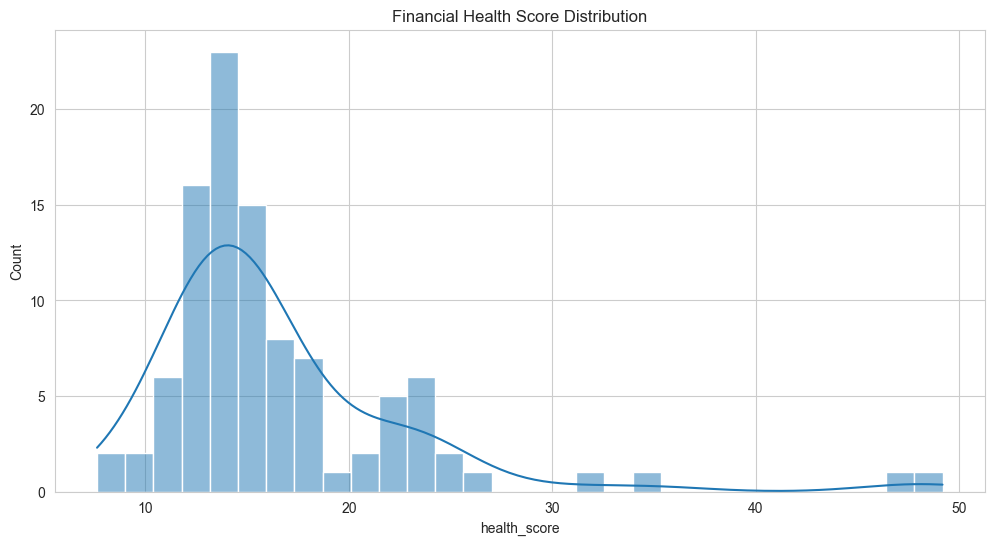

In [22]:
plt.figure(figsize=(12,6))

sns.histplot(
    company_metrics["health_score"],
    bins=30,
    kde=True
)

plt.title("Financial Health Score Distribution")

plt.show()

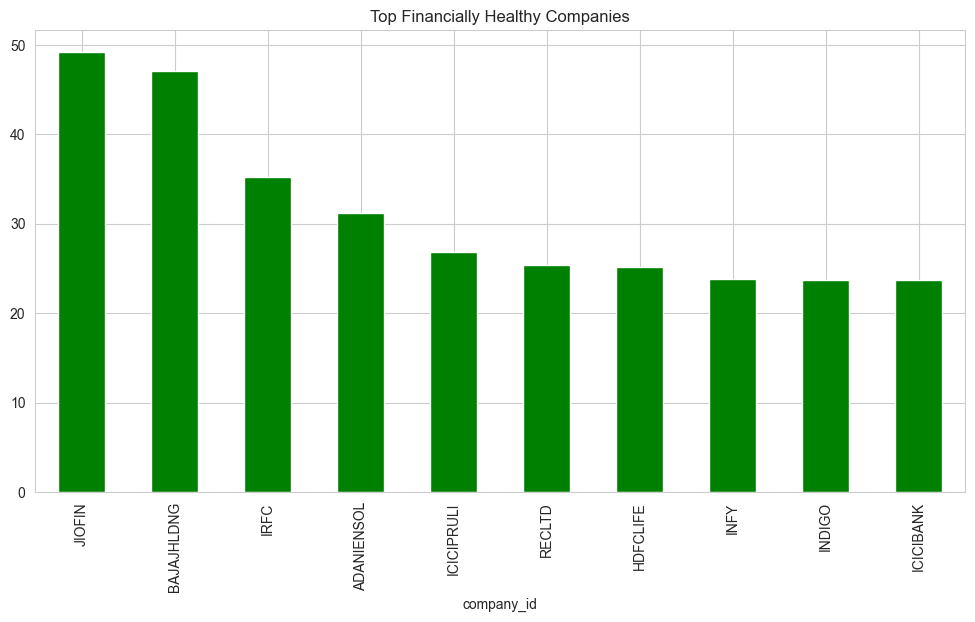

In [23]:
top_health = company_metrics.head(10)

top_health["health_score"].plot(
    kind="bar",
    figsize=(12,6),
    color="green"
)

plt.title("Top Financially Healthy Companies")

plt.show()

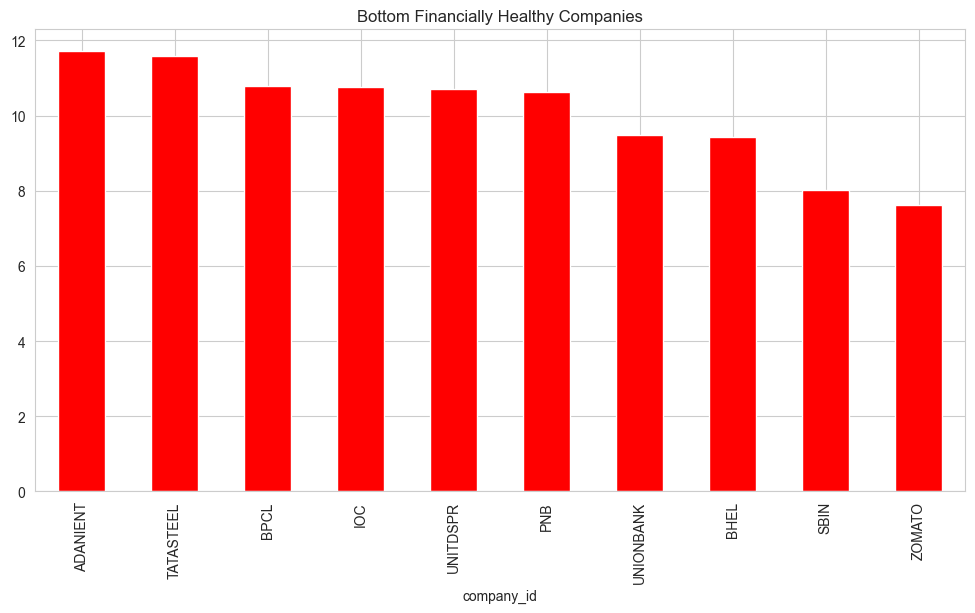

In [24]:
bottom_health = company_metrics.tail(10)

bottom_health["health_score"].plot(
    kind="bar",
    figsize=(12,6),
    color="red"
)

plt.title("Bottom Financially Healthy Companies")

plt.show()

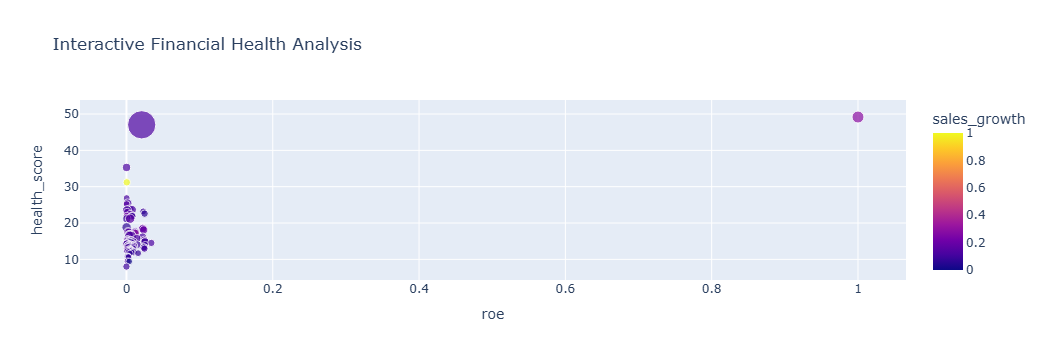

In [25]:
fig = px.scatter(
    company_metrics.reset_index(),
    x="roe",
    y="health_score",
    color="sales_growth",
    hover_name="company_id",
    size="net_margin",
    title="Interactive Financial Health Analysis"
)

fig.show()

In [26]:
company_metrics["roe"] = company_metrics["roe"].clip(
    upper=100
)

In [27]:
company_metrics["sales_growth"] = (
    company_metrics["sales_growth"]
    .clip(lower=-50, upper=100)
)

In [28]:
company_metrics["roe"] = (
    company_metrics["roe"]
    .clip(lower=0, upper=100)
)

company_metrics["sales_growth"] = (
    company_metrics["sales_growth"]
    .clip(lower=-50, upper=100)
)

company_metrics["interest_coverage"] = (
    company_metrics["interest_coverage"]
    .clip(lower=0, upper=100)
)

In [29]:
from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "net_margin",
    "operating_margin",
    "roe",
    "sales_growth",
    "interest_coverage",
    "asset_turnover"
]

scaler = MinMaxScaler()

company_metrics[score_columns] = scaler.fit_transform(
    company_metrics[score_columns]
)

In [30]:
company_metrics["health_score"] = (
    company_metrics["net_margin"] * 0.25 +
    company_metrics["operating_margin"] * 0.20 +
    company_metrics["roe"] * 0.20 +
    company_metrics["sales_growth"] * 0.15 +
    company_metrics["interest_coverage"] * 0.10 +
    company_metrics["asset_turnover"] * 0.10
) * 100

In [31]:
company_metrics = company_metrics.sort_values(
    "health_score",
    ascending=False
)

In [32]:
company_metrics.head(10)

,net_margin,operating_margin,interest_coverage,roe,debt_to_equity,asset_turnover,sales_growth,health_score
company_id,,,,,,,,
JIOFIN,0.180022,0.884534,0.203164,1.000000,0.002170,0.059143,0.290685,49.174579
BAJAJHLDNG,1.000000,0.891353,0.168128,0.020863,0.001263,0.009108,0.134419,47.032962
IRFC,0.084662,1.000000,0.121703,0.000140,8.573423,1.000000,0.130704,35.296959
ADANIENSOL,0.069996,0.661199,0.121772,0.000473,3.003669,0.000102,1.000000,31.202090
ICICIPRULI,0.059835,0.990353,0.349947,0.000330,0.052613,0.031382,0.116138,26.864909
RECLTD,0.093793,0.956507,0.121733,0.001659,6.467910,0.098459,0.114505,25.427632
HDFCLIFE,0.058357,0.985508,0.147647,0.000204,0.023586,0.020852,0.156937,25.212190
INFY,0.085472,0.491434,1.000000,0.004800,0.039647,0.000390,0.117635,23.829893
INDIGO,0.057239,0.928239,0.125032,0.001232,0.544598,0.000294,0.167123,23.780480


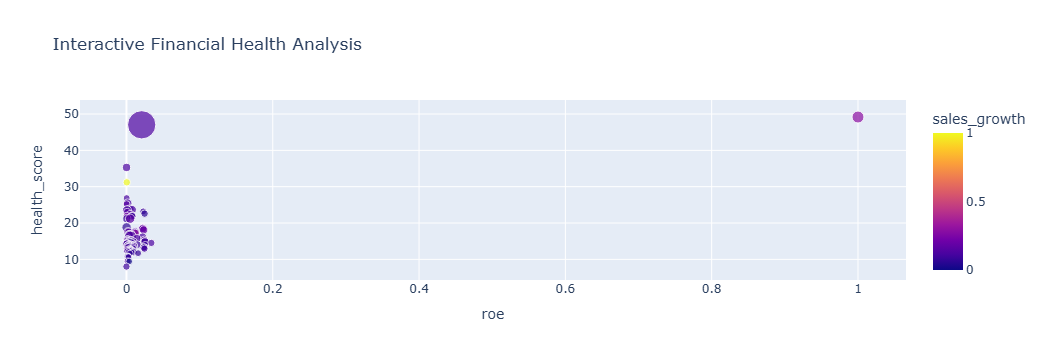

In [33]:
fig = px.scatter(
    company_metrics.reset_index(),
    x="roe",
    y="health_score",
    color="sales_growth",
    hover_name="company_id",
    size="net_margin",
    title="Interactive Financial Health Analysis"
)

fig.show()

In [34]:
famous_companies = [
    "TCS",
    "HDFCBANK",
    "WIPRO",
    "ADANIPOWER",
    "APOLLOHOSP"
]

validation = company_metrics.loc[
    company_metrics.index.intersection(famous_companies)
]

validation

,net_margin,operating_margin,interest_coverage,roe,debt_to_equity,asset_turnover,sales_growth,health_score
company_id,,,,,,,,
HDFCBANK,0.089662,0.583556,0.121758,0.022081,7.942761,0.019275,0.174034,18.375130
TCS,0.087188,0.501246,0.169429,0.022058,0.043843,0.000532,0.118237,16.118951
ADANIPOWER,0.056895,0.507776,0.121808,0.000252,10.182711,0.000107,0.165913,15.290797
WIPRO,0.078810,0.453472,0.124505,0.005196,0.226512,0.000282,0.085372,13.672062
APOLLOHOSP,0.060934,0.399866,0.122149,0.004658,0.817052,0.000133,0.138217,12.909906


In [35]:
company_metrics["growth_focused_score"] = (
    company_metrics["sales_growth"] * 0.40 +
    company_metrics["roe"] * 0.20 +
    company_metrics["net_margin"] * 0.15 +
    company_metrics["operating_margin"] * 0.15 +
    company_metrics["interest_coverage"] * 0.10
) * 100

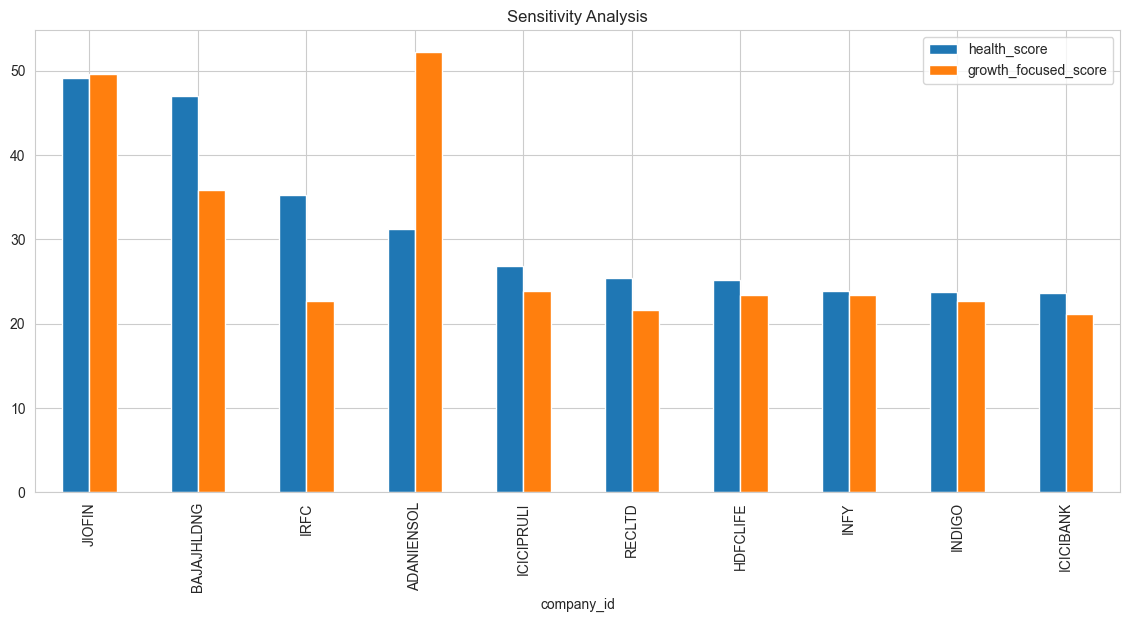

In [36]:
comparison = company_metrics[
    ["health_score", "growth_focused_score"]
]

comparison.head(10).plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Sensitivity Analysis")

plt.show()

In [37]:
company_metrics.to_csv(
    "exports/company_health_scores.csv"
)

In [38]:
import os

os.listdir("exports")

['clean_analysis.csv',
 'clean_balance_sheet.csv',
 'clean_cash_flow.csv',
 'clean_profit_loss.csv',
 'company_health_scores.csv',
 'sales_growth.csv']